In [2]:
import pandas as pd
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset
df = pd.read_csv('../audio.csv')
df.set_index('File_Name', inplace=True)

# Initialize lists for features and labels
features = []
labels = []
genders = [] 

# Read WAV files and extract features
for f in df.index:
    file_path = '../data/' + f
    try:
        signal, rate = librosa.load(file_path, sr=None)
        df.at[f, 'length'] = len(signal) / rate
        
        # Extract MFCCs
        mfccs = librosa.feature.mfcc(y=signal, sr=rate, n_mfcc=13)
        mfccs_mean = np.mean(mfccs, axis=1)

        if mfccs_mean.shape[0] == 13:
            features.append(mfccs_mean)
            labels.append(df.at[f, 'Emotion'])  
            genders.append(df.at[f, 'Gender'])  

    except Exception as e:
        print(f"Error processing file {file_path}: {e}")

# Convert features and labels to arrays
X = np.array(features)
y = np.array(labels)
genders = np.array(genders)

# Create a DataFrame
df_features = pd.DataFrame(X)
df_features['Emotion'] = y
df_features['Gender'] = genders

# Oversampling process
gender_distribution = df_features.groupby(['Emotion', 'Gender']).size()
max_count = gender_distribution.max()

# Initialize balanced DataFrame
balanced_df = pd.DataFrame()

for (emotion, gender), count in gender_distribution.items():
    label_df = df_features[(df_features['Emotion'] == emotion) & (df_features['Gender'] == gender)]
    if len(label_df) < max_count:
        label_df = label_df.sample(max_count, replace=True)
        
    balanced_df = pd.concat([balanced_df, label_df], ignore_index=True)

# Check the balanced dataset
print("Balanced dataset distribution:")
print(balanced_df['Emotion'].value_counts())
print(balanced_df['Gender'].value_counts())

# Prepare features and labels for the model
X_balanced = balanced_df.drop(columns=['Emotion', 'Gender']).values
y_balanced = balanced_df['Emotion'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42)

# Initialize the Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)

# Train the classifier
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Output the results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

Balanced dataset distribution:
Emotion
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral      192
sad          192
surprised    192
Name: count, dtype: int64
Gender
F    768
M    768
Name: count, dtype: int64
Accuracy: 0.49
Classification Report:
              precision    recall  f1-score   support

       angry       0.59      0.65      0.62        31
        calm       0.61      0.45      0.52        44
     disgust       0.37      0.30      0.33        33
     fearful       0.47      0.38      0.42        45
       happy       0.41      0.45      0.43        31
     neutral       0.63      0.88      0.74        52
         sad       0.38      0.32      0.35        37
   surprised       0.28      0.31      0.30        35

    accuracy                           0.49       308
   macro avg       0.47      0.47      0.46       308
weighted avg       0.48      0.49      0.48       308



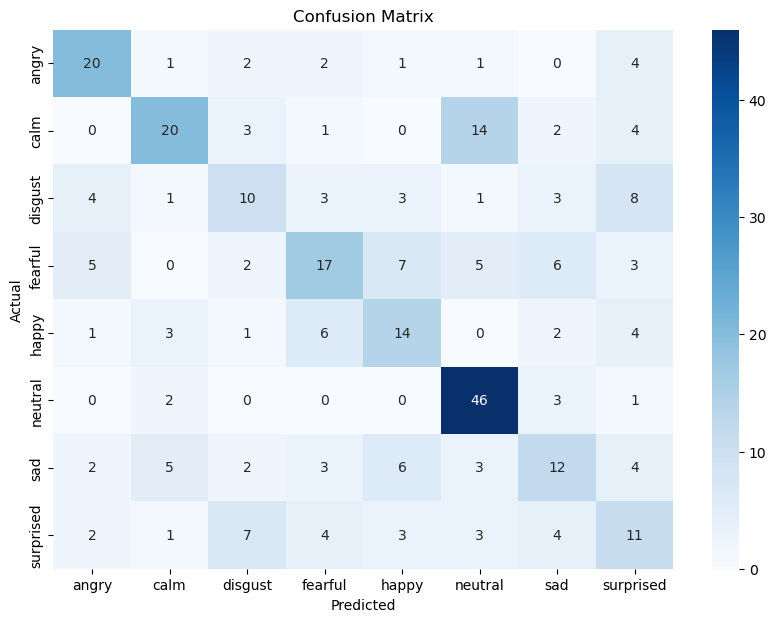

In [5]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_balanced), yticklabels=np.unique(y_balanced))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [8]:
df_features.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,Emotion,Gender
0,-726.217224,68.541420,3.293398,12.205300,5.510278,13.667408,-2.983828,3.098029,-3.310814,-1.564384,-7.861652,-2.124282,2.849204,neutral,M
1,-719.128296,70.201569,1.168397,13.122543,7.836950,14.411290,-4.111360,4.468973,-3.539367,-3.658607,-7.648504,-1.477077,3.031821,neutral,M
2,-714.995728,69.689346,3.924564,11.924190,6.421723,11.011614,-2.878103,4.509558,-4.476109,-2.671549,-7.499283,-2.962266,1.873485,neutral,M
3,-710.975281,67.564888,5.782241,13.230726,6.190845,12.628252,-1.675169,5.657494,-4.950634,-3.477545,-7.416558,-1.937004,2.271525,neutral,M
4,-759.921753,75.783524,6.023605,14.557394,6.454187,14.631508,-3.004551,4.620970,-5.200016,-0.707430,-7.790287,-3.564948,2.180970,calm,M
